In [1]:
import time
# autoreload
%load_ext autoreload
%autoreload 2

#from scipy import signal
#from scipy import interpolate
#from scipy import ndimage
import numpy as np
#import pycatch22 
#from sktime.transformations.panel import catch22
#import tsfresh
from tqdm import tqdm
import sys, os
import pandas as pd 
import dotenv
import random
load_dotenv = dotenv.load_dotenv('../.env')
# load local library
from timex import extractor
from timex import preprocessing
#import wavelets

import gc
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict

#from time import sleep

#from scipy.stats import skew, kurtosis
#from scipy.fft import rfft, rfftfreq
#from scipy.signal import cwt, ricker
#import pymannkendall as mk

# explicitly require this experimental feature
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
#from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AffinityPropagation, SpectralClustering, HDBSCAN
from sklearn.mixture import GaussianMixture as GMM
from umap import UMAP
#from scaler import GaussRankScaler
from sklearn.pipeline import Pipeline
#import nolds

import datetime
from time import sleep
#from numba import jit
#from typing import Union, List, Literal, Generator, Tuple


c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.12\Lib\site-packages\tsfresh\__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Wat ik heb gedaan:
* Voor inzicht in de inclusie van patiënten staat de inclusie flowchart in de map met resultaten. Daar vind je ook de baseline tabellen.
* De index van de eGFR trajecten is op dag 7 vanaf “AKI onset” en loopt tot max 3650 dagen.
* De data is geïnterpoleerd zodat er op iedere dag tot de laatste bekende meting van een patiënt (of tot uiterlijk dag 3650), een uitkomst geschat wordt. Die data is vervolgens vanaf dag 7 gesmooth met Gaussian kernel smoothing met een **smoothing window van 365 dagen**.
* Het is nu zo ingesteld dat de LCMM wordt uitgevoerd met een **tijdsresolutie van 365 dagen** (n=15257 AKI patiënten) en **90 dagen** (n=19785 AKI patiënten), **tot max 3650 dagen**. Dus hij neemt een meting mee op dag 7-365-730..3650 of 7-90-180-270..3650.
Alle modelfuncties zijn lineair, en de link-functies zijn lineair/beta/splines. De splines zijn standaard ingesteld op 5 interne knopen op kwantielen, maar dat kan ik eventueel wijzigen als dat nuttig is.
Alle modellen maken **2 t/m 8 clusters**.
 
De flowcharts, baseline tabellen en resultaten per LCMM staan in de volgende map:

```L:\laupodteam\AIOS\Denise\PROJECT 6. - Methods paper with Bram\Results```
 

In [2]:
START_TIME = datetime.datetime.now()

In [3]:
AKI_PATH = os.environ['AKI_PATH_NEW']
os.chdir(AKI_PATH)

In [4]:
AKI_PATH

'T:\\lab_research\\RES-Folder-UPOD\\NOSTRADAMUS_SALTRO\\E_ResearchData\\2_ResearchData\\CLEANED_for_Methods_paper_longitudinal_analysis\\28102025\\ANALYSIS\\BRAM'

In [5]:
os.listdir('.')

['cleaned_DV_LCMM_data.parquet', 'cleaned_DV_LCMM_data.Rdata']

In [6]:
ts_data = pd.read_parquet(os.path.join(AKI_PATH, 'cleaned_DV_LCMM_data.parquet'))

In [ ]:
ts_data.head()

,ID,Date,eGFRcr_CKDEpi2009,Time_since_index_FU_days,eGFR_int,eGFR_SW30,eGFR_SW365,dataset_nr
0,55870.0,1994-09-02 08:00:00+00:00,18.592316,0.0,18.592316,18.592316,18.592316,1.0
1,55870.0,NaT,NaN,1.0,18.635299,19.669504,23.543553,1.0
2,55870.0,NaT,NaN,2.0,18.678282,19.759267,23.547455,1.0
3,55870.0,NaT,NaN,3.0,18.721266,19.855523,23.551345,1.0
4,55870.0,NaT,NaN,4.0,18.764249,19.958323,23.555221,1.0


In [8]:
ts_data = ts_data.rename(columns={"Time_since_index_FU_days": "Time_days"})

In [9]:
ts_data.ID = ts_data.ID.astype('int64')

In [42]:
ts_data

,ID,Date,eGFRcr_CKDEpi2009,Time_days,eGFR_int,eGFR_SW30,eGFR_SW365,dataset_nr
0,55870,1994-09-02 08:00:00+00:00,18.592316,0.000000,18.592316,18.592316,18.592316,1.0
1,55870,NaT,NaN,1.000000,18.635299,19.669504,23.543553,1.0
2,55870,NaT,NaN,2.000000,18.678282,19.759267,23.547455,1.0
3,55870,NaT,NaN,3.000000,18.721266,19.855523,23.551345,1.0
4,55870,NaT,NaN,4.000000,18.764249,19.958323,23.555221,1.0
...,...,...,...,...,...,...,...,...
14931643,18639312134,NaT,NaN,775.000000,49.246268,49.121731,48.865860,1.0
14931644,18639312134,NaT,NaN,776.000000,49.264663,49.129569,48.861135,1.0
14931645,18639312134,NaT,NaN,777.000000,49.283058,49.137004,48.856455,1.0
14931646,18639312134,NaT,NaN,778.000000,49.301453,49.144053,48.851819,1.0


In [ ]:
# We want a minimum of 2 time points to do any kind of time series analysis
counts = ts_data.groupby('ID').size()
ts_data =  ts_data.loc[ts_data.ID.isin(counts[counts>=2].index)]

<Axes: >

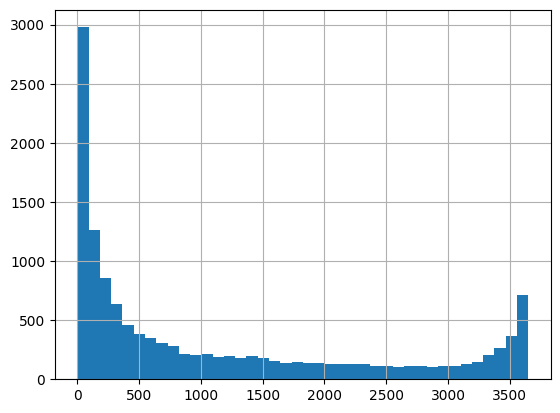

In [54]:
ts_data.groupby('ID').Time_days.max().hist(bins=40)

In [9]:
# load pre-selection
#ts_data = pd.read_parquet("./Bram_v2/test_data.parquet")
#ts_data = ts_data.assign(ID=ts_data.ID.astype('int64'))

#d = pd.to_datetime(ts_data.lab_date).dt.date - pd.to_datetime(ts_data.Start_AKI_episode_1).dt.date
#ts_data['Time_days'] = d.apply(lambda x: x.days)

In [45]:
patient_cardinality = ts_data.groupby('ID').size().to_frame().rename(columns={0: 'count'})

In [55]:
patient_cardinality.loc[patient_cardinality['count']>30]

,count
ID,
55870,269
3565782,1628
7420534,259
8244422,2377
8266790,750
...,...
18636225350,1377
18637774334,2260
18638734294,186


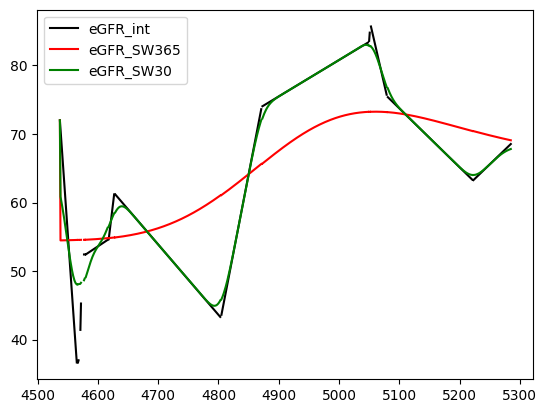

In [57]:
_id = 8266790
plt.plot(ts_data.loc[ts_data.ID==_id, 'eGFR_int'], color='black')
plt.plot(ts_data.loc[ts_data.ID==_id, 'eGFR_SW365'], color='red')
plt.plot(ts_data.loc[ts_data.ID==_id, 'eGFR_SW30'], color='green')

plt.legend(['eGFR_int', 'eGFR_SW365', 'eGFR_SW30'])

In [63]:
ts_data_raw = ts_data.dropna(subset=['eGFRcr_CKDEpi2009']).drop(['Date', 'eGFR_int', 'eGFR_SW30', 'eGFR_SW365', 'dataset_nr'], axis=1)

In [64]:
ts_data_raw.head()

,ID,eGFRcr_CKDEpi2009,Time_days
0,55870,18.592316,0.000000
15,55870,19.196082,14.046528
22,55870,24.349929,20.152778
30,55870,26.234011,27.166667
45,55870,16.648273,41.229167


In [13]:
ID_COL = "ID"
VAL_COL = "eGFR_int"
TIME_COL = "Time_days"

In [14]:
ts_data = ts_data[[ID_COL, VAL_COL, TIME_COL]]

## Exploration

In [59]:
min_days_length = 1*10
maxts = ts_data.groupby('ID').Time_days.max()
ltids = maxts[maxts>min_days_length].index

print(f'There are {ltids.shape[0]} patients (or {round(100*ltids.shape[0]/maxts.shape[0], 2)}%) with minimally {min_days_length} days of measurements')

There are 12732 patients (or 97.67%) with minimally 10 days of measurements


## Aggregregate per min time unit (a day in this case)

In [16]:
ts_data = ts_data.groupby(['ID', 'Time_days'])[VAL_COL].mean().reset_index()

<Axes: >

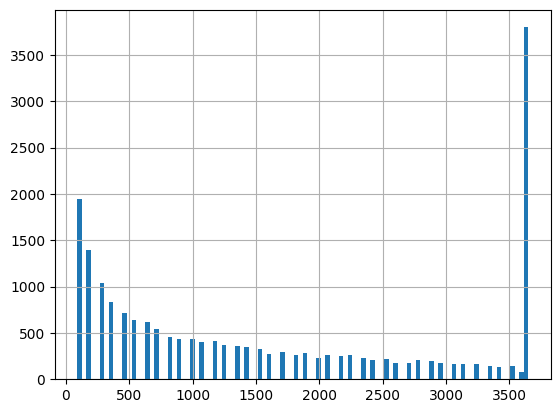

In [17]:
ts_data.groupby('ID').Time_days.max().hist(bins=100)

In [18]:
time_offset = 7
ts_data[TIME_COL]= ts_data[TIME_COL] - time_offset

## Preprocess

In [19]:
# TODONE: SOLVED with Nskip parameter in smoothing functions; make sure the first measurement is not affect by smoothing
# TODONE: just group by; check time resolution unit -> might be multiple measurement per minimum timeunit (e.g. multiple measurements per day)
# TODONE: add option to get_filtered_df to select based on closedness to first AKI


In [ ]:
RangeList = [720, 1800, 3600] #+ list(np.arange(1*365,10*365, 365))

WINDOW_SIZE = 3 # for smoothing
MIN_MEASUREMENTS_PER_YEAR = 0.
SMOOTHING_TYPE = 'gaussian_kernel' #'gaussian_kernel' # rolling_mean or gaussian_kernel
STANDARDIZE_TYPE = 'minmax'
TIME_RESOLUTION = 30 # in days, for interpolation.
CLUSTER_NUM_LIST = [4,  6,  8,  16, 24, 32]
NUM_BEFORE_FIRST_AKI = 0 # NBFA
NUM_SKIP = 1 # NS
TEST = False
keep_t0_value = True
WRITE_OUT_PREPPED = False

custom_features = True # [X]
tsfresh_features = False # [X]
catch22_features = False # [X]
cesium_features = False # [X]
antropy_features = False # [X]
nolds_features = False # [X]
katz_features = False # [X]
tsfel_features = False # [X]

SEL_BEFORE_AKI = False

In [21]:
if SEL_BEFORE_AKI:
    ts_data['time_rank'] = ts_data.sort_values(by=[ID_COL, TIME_COL])\
                                .groupby(ID_COL).Time_days.rank()
    tmp = ts_data.loc[ts_data.Time_days==0][[ID_COL,'time_rank']]\
                .rename(columns={'time_rank': 'time_rank_zero'})
    ts_data = ts_data.merge(tmp, on=ID_COL, how='left')
    ts_data = ts_data.loc[ts_data[['time_rank', 'time_rank_zero']]\
                        .apply(lambda x: (x[0]-x[1])>=-NUM_BEFORE_FIRST_AKI, axis=1),
                        [ID_COL, TIME_COL, VAL_COL]]


In [22]:
if TEST:
    # Select 100 patients
    RND_SELECTION = ts_data[ID_COL].unique()[np.random.randint(0,ts_data[ID_COL].nunique(), 500)]
    ts_data = ts_data.loc[ts_data[ID_COL].isin(RND_SELECTION)]

RangeDFDict = {'raw': defaultdict(pd.DataFrame), 
                'normalised': defaultdict(pd.DataFrame)}
RangeDFDict_smoothed = {'raw': defaultdict(pd.DataFrame), 
                        'normalised': defaultdict(pd.DataFrame)}

for MinDays in RangeList:    
    MIN_MEASUREMENTS = np.floor(MIN_MEASUREMENTS_PER_YEAR*MinDays/365)
    
    print(f'Filtering for min days: {MinDays}')
    ts_temp = preprocessing.get_filtered_df(ts_data.copy(), 
                                            id_col=ID_COL, 
                                            time_col=TIME_COL,
                                            min_days=MinDays, 
                                            min_measurements=MIN_MEASUREMENTS)    
    
    remaining_ids = ts_temp[ID_COL].unique()
    print(f'Interpolating for min days: {MinDays}')
    RangeDFDict['raw'][MinDays] = preprocessing.get_interpolated(ts_temp, id_col=ID_COL, 
                                                          time_col=TIME_COL,
                                                          max_days=MinDays,
                                                          days_before=NUM_BEFORE_FIRST_AKI,
                                                          val_col=VAL_COL,
                                                          time_res=TIME_RESOLUTION,
                                                          keep_t0_value=keep_t0_value,
                                                          df_out=True)
    
    print(f"Smoothing for min days: {MinDays} with window {WINDOW_SIZE}")
    if SMOOTHING_TYPE == 'rolling_mean':
        RangeDFDict_smoothed['raw'][MinDays] = preprocessing.get_smoothed_rolling_mean(RangeDFDict['raw'][MinDays].copy(),
                                                        id_col=ID_COL,
                                                        time_col=TIME_COL,
                                                        val_col=VAL_COL, 
                                                        window=WINDOW_SIZE,
                                                        Nskip=NUM_SKIP, 
                                                        df_out=True)
    elif SMOOTHING_TYPE == 'gaussian_kernel':
        RangeDFDict_smoothed['raw'][MinDays] = preprocessing.get_smoothed_gaussian_kernel(RangeDFDict['raw'][MinDays].copy(),
                                                        id_col=ID_COL, 
                                                        time_col=TIME_COL,
                                                        val_col=VAL_COL, 
                                                        window=WINDOW_SIZE,
                                                        Nskip=NUM_SKIP,
                                                        df_out=True)

    print(f'Standardizing for min days: {MinDays}')
    RangeDFDict['normalised'][MinDays] = preprocessing.normalise_ts(
                                         RangeDFDict['raw'][MinDays], 
                                         id_col=ID_COL, 
                                         time_col=TIME_COL,
                                         val_col=VAL_COL,
                                         df_out=True,
                                         scaler=STANDARDIZE_TYPE)
    
    RangeDFDict_smoothed['normalised'][MinDays] = preprocessing.normalise_ts(
                                         RangeDFDict_smoothed['raw'][MinDays], 
                                         id_col=ID_COL, 
                                         time_col=TIME_COL,
                                         val_col=VAL_COL,
                                         df_out=True,
                                         scaler=STANDARDIZE_TYPE)
    

Filtering for min days: 720
Interpolating for min days: 720


100%|██████████| 298/298 [00:00<00:00, 992.82it/s]


Smoothing for min days: 720 with window 3


100%|██████████| 298/298 [00:00<00:00, 850.82it/s]


Standardizing for min days: 720


...

100%|██████████| 100/100 [00:00<00:00, 1198.87it/s]


Smoothing for min days: 3600 with window 3


100%|██████████| 100/100 [00:00<00:00, 857.32it/s]


Standardizing for min days: 3600


100%|██████████| 100/100 [00:00<00:00, 199.17it/s]


2628431942


Text(0.5, 0, 'Time in days')

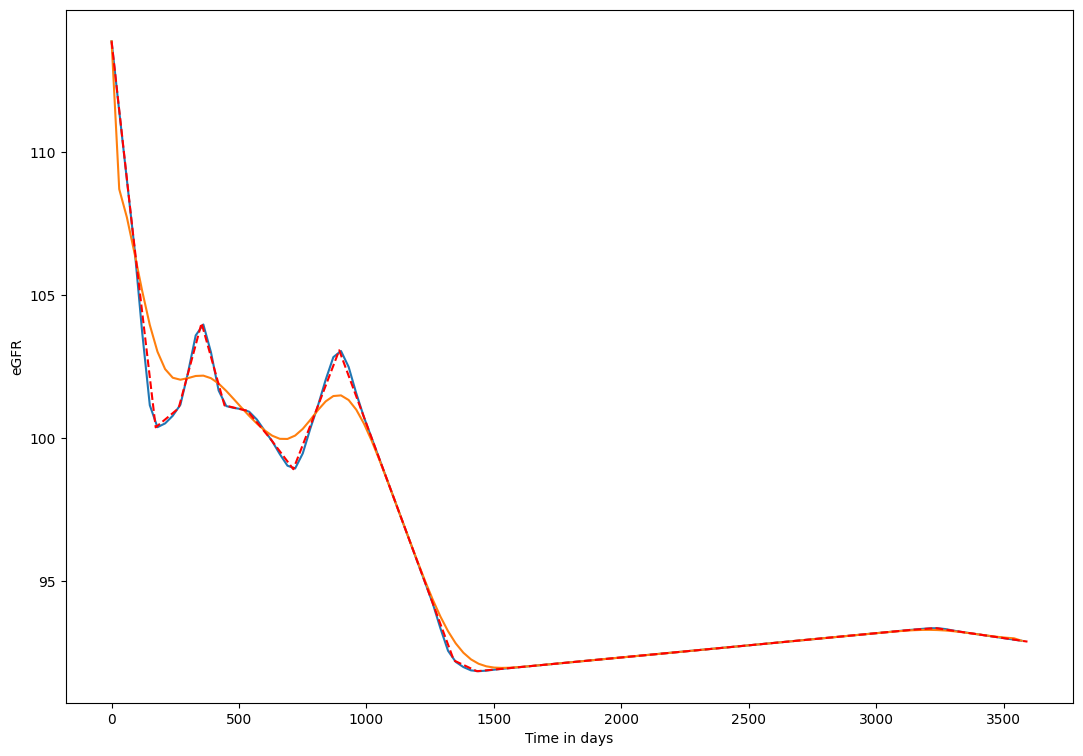

In [24]:
# Write prepped TS to disk
Range = 3600
IDSEL = 7 # 31974771
_ID = remaining_ids[IDSEL]
print(_ID)

x_or = ts_data.query(f'ID=={_ID} & Time_days<={Range}')[TIME_COL]
y_or = ts_data.query(f'ID=={_ID} & Time_days<={Range}')[VAL_COL]

x = RangeDFDict['raw'][Range].query(f'ID=={_ID}')[TIME_COL]
y = RangeDFDict['raw'][Range].query(f'ID=={_ID}')[VAL_COL]

xs = RangeDFDict_smoothed['raw'][Range].query(f'ID=={_ID}')[TIME_COL]
ys = RangeDFDict_smoothed['raw'][Range].query(f'ID=={_ID}')[VAL_COL]

plt.figure(figsize=(13,9))
plt.plot(x[:Range], y[:Range])
plt.plot(xs[:Range], ys[:Range])
plt.plot(x_or[:Range], y_or[:Range], color='red', linestyle='--')
plt.ylabel("eGFR")
plt.xlabel("Time in days")

In [25]:
# Write prepared timeseries to file
if WRITE_OUT_PREPPED:
    for k, v in RangeDFDict_smoothed.items():
        for _k, _v in v.items():
            _v.to_parquet(f"ts_smoothed_{k}_TR{TIME_RESOLUTION}_ST{SMOOTHING_TYPE}_{_k}_NS{NUM_SKIP}_NBFA{NUM_BEFORE_FIRST_AKI}_SW{WINDOW_SIZE}_ST{STANDARDIZE_TYPE}.parquet")
            
    for k, v in RangeDFDict.items():
        for _k, _v in v.items():
            _v.to_parquet(f"ts_raw_{k}_{_k}_TR{TIME_RESOLUTION}_NS{NUM_SKIP}_NBFA{NUM_BEFORE_FIRST_AKI}_SW{WINDOW_SIZE}_ST{STANDARDIZE_TYPE}.parquet")

In [26]:
CrossSectDict = {}
# get_smoothNsmooth_diffStatistics
for MinDays in RangeList:
    print(f'RAW: Getting cross-sectional features for min days, for the smoothed set, with periods of: {MinDays} days')
    tsS = RangeDFDict_smoothed['raw'][MinDays]
    smoothed_cross_nonnorm, timings = extractor.get_crossectional(tsS, 
                                        id_col=ID_COL,
                                        val_col=VAL_COL,
                                        time_col=TIME_COL,
                                        custom_features=custom_features,
                                        tsfresh_features=tsfresh_features,
                                        catch22_features=catch22_features,
                                        cesium_features=cesium_features,
                                        antropy_features=antropy_features,
                                        nolds_features=nolds_features,
                                        katz_features=katz_features,
                                        tsfel_features=tsfel_features)
    ############
    print(f'RAW: Getting cross-sectional features for min days, for the raw set, with periods of: {MinDays} days')
    tsR = RangeDFDict['raw'][MinDays]
    raw_cross_nonnorm, _ = extractor.get_crossectional(tsR, 
                                        id_col=ID_COL,
                                        val_col=VAL_COL,
                                        time_col=TIME_COL,
                                        custom_features=custom_features,
                                        tsfresh_features=tsfresh_features,
                                        catch22_features=catch22_features,
                                        cesium_features=cesium_features,
                                        antropy_features=antropy_features,
                                        nolds_features=nolds_features,
                                        katz_features=katz_features,
                                        tsfel_features=tsfel_features)
    ############
    print(f'RAW: Merging cross-sectional features for min days, the raw set, with periods of: {MinDays} days')
    merged_cross_nonnorm = smoothed_cross_nonnorm.merge(raw_cross_nonnorm,
                                        left_index=True, 
                                        right_index=True, 
                                        suffixes=('_smoothed', '_raw'))
    smoothNsmoothStats = extractor.get_smoothNsmooth_diffStatistics(tsS,tsR, 
                                                                    id_col=ID_COL,
                                                                    val_col=VAL_COL,
                                                                    time_col=TIME_COL)
    
    smoothed_cross_nonnorm = smoothed_cross_nonnorm.merge(smoothNsmoothStats, left_index=True, right_index=True)
    raw_cross_nonnorm = raw_cross_nonnorm.merge(smoothNsmoothStats, left_index=True, right_index=True)
    merged_cross_nonnorm = merged_cross_nonnorm.merge(smoothNsmoothStats, left_index=True, right_index=True)
    
    smoothed_cross_nonnorm.columns = [f"{c}_NONNORM" for c in smoothed_cross_nonnorm.columns]
    raw_cross_nonnorm.columns = [f"{c}_NONNORM" for c in raw_cross_nonnorm.columns]
    merged_cross_nonnorm.columns = [f"{c}_NONNORM" for c in merged_cross_nonnorm.columns]
        
    #|||||||||||||||||||||||||||||
    #|||||||||||||||||||||||||||||
    
    print(f'NORMALISED: Getting cross-sectional features for min days, for the smoothed set, with periods of: {MinDays} days')
    tsS = RangeDFDict_smoothed['normalised'][MinDays]
    smoothed_cross_norm, _ = extractor.get_crossectional(tsS, 
                                        id_col=ID_COL,
                                        val_col=VAL_COL,
                                        time_col=TIME_COL,
                                        custom_features=custom_features,
                                        tsfresh_features=tsfresh_features,
                                        catch22_features=catch22_features,
                                        cesium_features=cesium_features,
                                        antropy_features=antropy_features,
                                        nolds_features=nolds_features,
                                        katz_features=katz_features,
                                        tsfel_features=tsfel_features)
    ############
    print(f'NORMALISED: Getting cross-sectional features for min days, for the raw set, with periods of: {MinDays} days')
    tsR = RangeDFDict['normalised'][MinDays]
    raw_cross_norm, _ = extractor.get_crossectional(tsR, 
                                        id_col=ID_COL,
                                        val_col=VAL_COL,
                                        time_col=TIME_COL,
                                        custom_features=custom_features,
                                        tsfresh_features=tsfresh_features,
                                        catch22_features=catch22_features,
                                        cesium_features=cesium_features,
                                        antropy_features=antropy_features,
                                        nolds_features=nolds_features,
                                        katz_features=katz_features,
                                        tsfel_features=tsfel_features)
    ############
    print(f'NORMALISED: Merging cross-sectional features for min days, the raw set, with periods of: {MinDays} days')
    merged_cross_norm = smoothed_cross_norm.merge(raw_cross_norm,
                                        left_index=True, 
                                        right_index=True, 
                                        suffixes=('_smoothed', '_raw'))
    smoothNsmoothStats = extractor.get_smoothNsmooth_diffStatistics(tsS,tsR, 
                                                                    id_col=ID_COL,
                                                                    val_col=VAL_COL,
                                                                    time_col=TIME_COL)
    
    smoothed_cross_norm = smoothed_cross_norm.merge(smoothNsmoothStats, left_index=True, right_index=True)
    raw_cross_norm = raw_cross_norm.merge(smoothNsmoothStats, left_index=True, right_index=True)
    merged_cross_norm = merged_cross_norm.merge(smoothNsmoothStats, left_index=True, right_index=True)
  
    smoothed_cross_norm.columns = [f"{c}_NORM" for c in smoothed_cross_norm.columns]
    raw_cross_norm.columns = [f"{c}_NORM" for c in raw_cross_norm.columns]
    merged_cross_norm.columns = [f"{c}_NORM" for c in merged_cross_norm.columns]
    
    # TODO: merge normalised and non_normalised
      
    smoothed_cross = smoothed_cross_norm.join(smoothed_cross_nonnorm, how='inner')
    raw_cross = raw_cross_norm.join(raw_cross_nonnorm, how='inner')
    merged_cross = merged_cross_norm.join(merged_cross_nonnorm, how='inner')
    
    CrossSectDict[MinDays] = {
                              'smoothed': smoothed_cross,
                              'raw': raw_cross,
                              'merged': merged_cross
                            }
    
    gc.collect()

RAW: Getting cross-sectional features for min days, for the smoothed set, with periods of: 720 days
Processing custom features..


  0%|          | 0/298 [00:00<?, ?it/s]c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.11\Lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 3 is too high: all coefficients will experience boundary effects.
  warnings.warn(
  0%|          | 1/298 [00:03<19:18,  3.90s/it]c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.11\Lib\site-packages\scipy\stats\_entropy.py:147: RuntimeWarning: divide by zero encountered in divide
  pk = 1.0*pk / xp.sum(pk, axis=axis, keepdims=True)  # type: ignore[operator]
100%|██████████| 298/298 [00:06<00:00, 47.95it/s] 


Processing tsfel features..


  7%|▋         | 22/298 [00:00<00:01, 214.26it/s]

positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_frequency
spectral_roll_on
spectral_roll_off
spectral_positive_turning
spectral_variation
spectral_slope
spectral_spread
spectral_skewness
spectral_kurtosis
spectral_decrease
spectral_centroid
spectral_distance
spectral_entropy
median_frequency
max_frequency
max_power_spectrum
wavelet_entropy
wavelet_abs_mean
wavelet_std
wavelet_energy
mfcc
lpcc
positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_frequency
spectral_roll_on
spectral_roll_off
spectral_positive_turning
spectral_variation
spectral_slope
spectral_spread
spectral_skewness
spectral_kurtosis
spectral_decrease
spectral_centroid
spectral_distance
spectral_entropy
median_frequency
max_frequency
max_power_spectrum
wavelet_entropy
wavelet_abs_mean
wavelet_std
wavelet_energy
mfcc
lpcc
positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_f

...

positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_frequency
spectral_roll_on
spectral_roll_off
spectral_positive_turning
spectral_variation
spectral_slope
spectral_spread
spectral_skewness
spectral_kurtosis
spectral_decrease
spectral_centroid
spectral_distance
spectral_entropy
median_frequency
max_frequency
max_power_spectrum
wavelet_entropy
wavelet_abs_mean
wavelet_std
wavelet_energy
mfcc
lpcc
positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_frequency
spectral_roll_on
spectral_roll_off
spectral_positive_turning
spectral_variation
spectral_slope
spectral_spread
spectral_skewness
spectral_kurtosis
spectral_decrease
spectral_centroid
spectral_distance
spectral_entropy
median_frequency
max_frequency
max_power_spectrum
wavelet_entropy
wavelet_abs_mean
wavelet_std
wavelet_energy
mfcc
lpcc
positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_f

 70%|███████   | 70/100 [00:00<00:00, 221.76it/s]

positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_frequency
spectral_roll_on
spectral_roll_off
spectral_positive_turning
spectral_variation
spectral_slope
spectral_spread
spectral_skewness
spectral_kurtosis
spectral_decrease
spectral_centroid
spectral_distance
spectral_entropy
median_frequency
max_frequency
max_power_spectrum
wavelet_entropy
wavelet_abs_mean
wavelet_std
wavelet_energy
mfcc
lpcc
positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_frequency
spectral_roll_on
spectral_roll_off
spectral_positive_turning
spectral_variation
spectral_slope
spectral_spread
spectral_skewness
spectral_kurtosis
spectral_decrease
spectral_centroid
spectral_distance
spectral_entropy
median_frequency
max_frequency
max_power_spectrum
wavelet_entropy
wavelet_abs_mean
wavelet_std
wavelet_energy
mfcc
lpcc
positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_f

100%|██████████| 100/100 [00:00<00:00, 229.58it/s]



positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_frequency
spectral_roll_on
spectral_roll_off
spectral_positive_turning
spectral_variation
spectral_slope
spectral_spread
spectral_skewness
spectral_kurtosis
spectral_decrease
spectral_centroid
spectral_distance
spectral_entropy
median_frequency
max_frequency
max_power_spectrum
wavelet_entropy
wavelet_abs_mean
wavelet_std
wavelet_energy
mfcc
lpcc
positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_frequency
spectral_roll_on
spectral_roll_off
spectral_positive_turning
spectral_variation
spectral_slope
spectral_spread
spectral_skewness
spectral_kurtosis
spectral_decrease
spectral_centroid
spectral_distance
spectral_entropy
median_frequency
max_frequency
max_power_spectrum
wavelet_entropy
wavelet_abs_mean
wavelet_std
wavelet_energy
mfcc
lpcc
positive_turning
negative_turning
travelled_distance
auc
lempel_ziv
median_abs_deviation
fundamental_

## Remove redundant features

In [27]:
# remove features that have more than N% of missing values
MAX_MISSING_VALUES_PER_COLUMN = 0.5

print("Removing features for all periods that are too sparse")
num_rem = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        missing_ratio = FINAL_FEATURES.isna().sum(axis=0)/\
                            FINAL_FEATURES.shape[0]
        missing_cols = missing_ratio[missing_ratio>MAX_MISSING_VALUES_PER_COLUMN].index
        
        CrossSectDict[period][key] = FINAL_FEATURES.drop(columns=missing_cols)
        num_rem.append(missing_cols.shape[0])
        
print(f"Number of columns removed: {num_rem}")

Removing features for all periods that are too sparse


100%|██████████| 3/3 [00:00<00:00, 142.46it/s]

Number of columns removed: [65, 69, 134, 65, 68, 133, 65, 65, 130]


In [28]:
# remove plus or minus infinity values
print("Removing infinite values")
num_rem = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        inf_cols = FINAL_FEATURES.columns[FINAL_FEATURES.isin([np.inf, -np.inf]).any()]
        CrossSectDict[period][key] = FINAL_FEATURES.drop(columns=inf_cols)
        num_rem.append(inf_cols.shape[0])

Removing infinite values


100%|██████████| 3/3 [00:00<00:00, 34.56it/s]


In [29]:
from sklearn.feature_selection import VarianceThreshold

print("Removing zero variance features for all periods...")
num_zero = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        
        var_thresh = VarianceThreshold(threshold=0.)
        var_thresh.fit(FINAL_FEATURES)
        variances = var_thresh.variances_

        # remove features with zero variance
        zero_variance_features = FINAL_FEATURES.columns[variances == 0]
        non_zero_variance_features = FINAL_FEATURES.columns[variances > 0]
        FINAL_FEATURES = FINAL_FEATURES.drop(zero_variance_features, axis=1)
        
        CrossSectDict[period][key] = FINAL_FEATURES
        num_zero.append(zero_variance_features.shape[0])  
        
print(f"Number of columns removed: {num_zero}")

Removing zero variance features for all periods...


100%|██████████| 3/3 [00:00<00:00, 56.40it/s]

Number of columns removed: [13, 7, 20, 9, 7, 16, 11, 7, 18]


In [30]:
# remove features that are highly correlated
print("Removing perfectly correlated features for all periods...")
num_corr = []
duplicated = set()
for period in CrossSectDict.keys():
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        
        #dist_matrix = 1-FINAL_FEATURES.corr(method='spearman').abs()
        #cols = dist_matrix.columns        
        cols = FINAL_FEATURES.columns
        droplist = []
        keeplist = []
        for i,cl in tqdm(enumerate(cols)):
            for cr in cols[i+1:]:
                if FINAL_FEATURES[cl].equals(FINAL_FEATURES[cr]):
                    keeplist.append(cl)
                    droplist.append(cr)
                    duplicated.add((cl, cr))
        to_drop = list(set(droplist).difference(set(keeplist)))
        
                
        FINAL_FEATURES = FINAL_FEATURES.drop(columns=to_drop)
        CrossSectDict[period][key] = FINAL_FEATURES
        num_corr.append(len(to_drop))
print(f"Number of columns removed: {num_corr}")

Removing perfectly correlated features for all periods...


308it [00:01, 296.67it/s]
314it [00:00, 383.83it/s]
610it [00:03, 197.85it/s]
308it [00:00, 429.39it/s]
310it [00:00, 413.30it/s]
606it [00:02, 203.79it/s]
306it [00:00, 330.77it/s]
310it [00:00, 313.78it/s]
604it [00:03, 188.61it/s]

Number of columns removed: [28, 30, 59, 29, 30, 60, 28, 30, 59]


In [31]:
print(f"Duplicate column-pairs: {duplicated}")


Duplicate column-pairs: {('custom_wvt_scale_max_0_raw_NORM', 'custom_wvt_scale_max_0_raw_NONNORM'), ('Frequency 5_0_raw_NORM', 'Frequency 5_0_raw_NONNORM'), ('LPCC_4_NONNORM', 'LPCC_8_NONNORM'), ('LPCC_4_raw_NONNORM', 'LPCC_8_raw_NONNORM'), ('fundamental_frequency_smoothed_NORM', 'fundamental_frequency_smoothed_NONNORM'), ('Frequency 6_0_NORM', 'Frequency 6_0_NONNORM'), ('loc_5_0_NORM', 'loc_5_0_NONNORM'), ('Frequency 6_0_smoothed_NORM', 'Frequency 6_0_smoothed_NONNORM'), ('loc_5_0_raw_NORM', 'loc_5_0_raw_NONNORM'), ('positive_turning_NORM', 'positive_turning_NONNORM'), ('rel_slope_sign_switch_sum_0_smoothed_NORM', 'rel_slope_sign_switch_sum_0_smoothed_NONNORM'), ('spectral_roll_off_raw_NORM', 'max_frequency_raw_NORM'), ('mann_kendall_Tau_0_raw_NORM', 'mann_kendall_Tau_0_raw_NONNORM'), ('mann_kendall_var_s_0_NORM', 'mann_kendall_var_s_0_NONNORM'), ('loc_3_0_NORM', 'loc_3_0_NONNORM'), ('Frequency 5_0_smoothed_NORM', 'Frequency 5_0_smoothed_NONNORM'), ('mann_kendall_s_0_NORM', 'mann_kend

In [32]:
CrossSectDict.keys()

dict_keys([720, 1800, 3600])

<Axes: >

<Figure size 2000x1000 with 0 Axes>

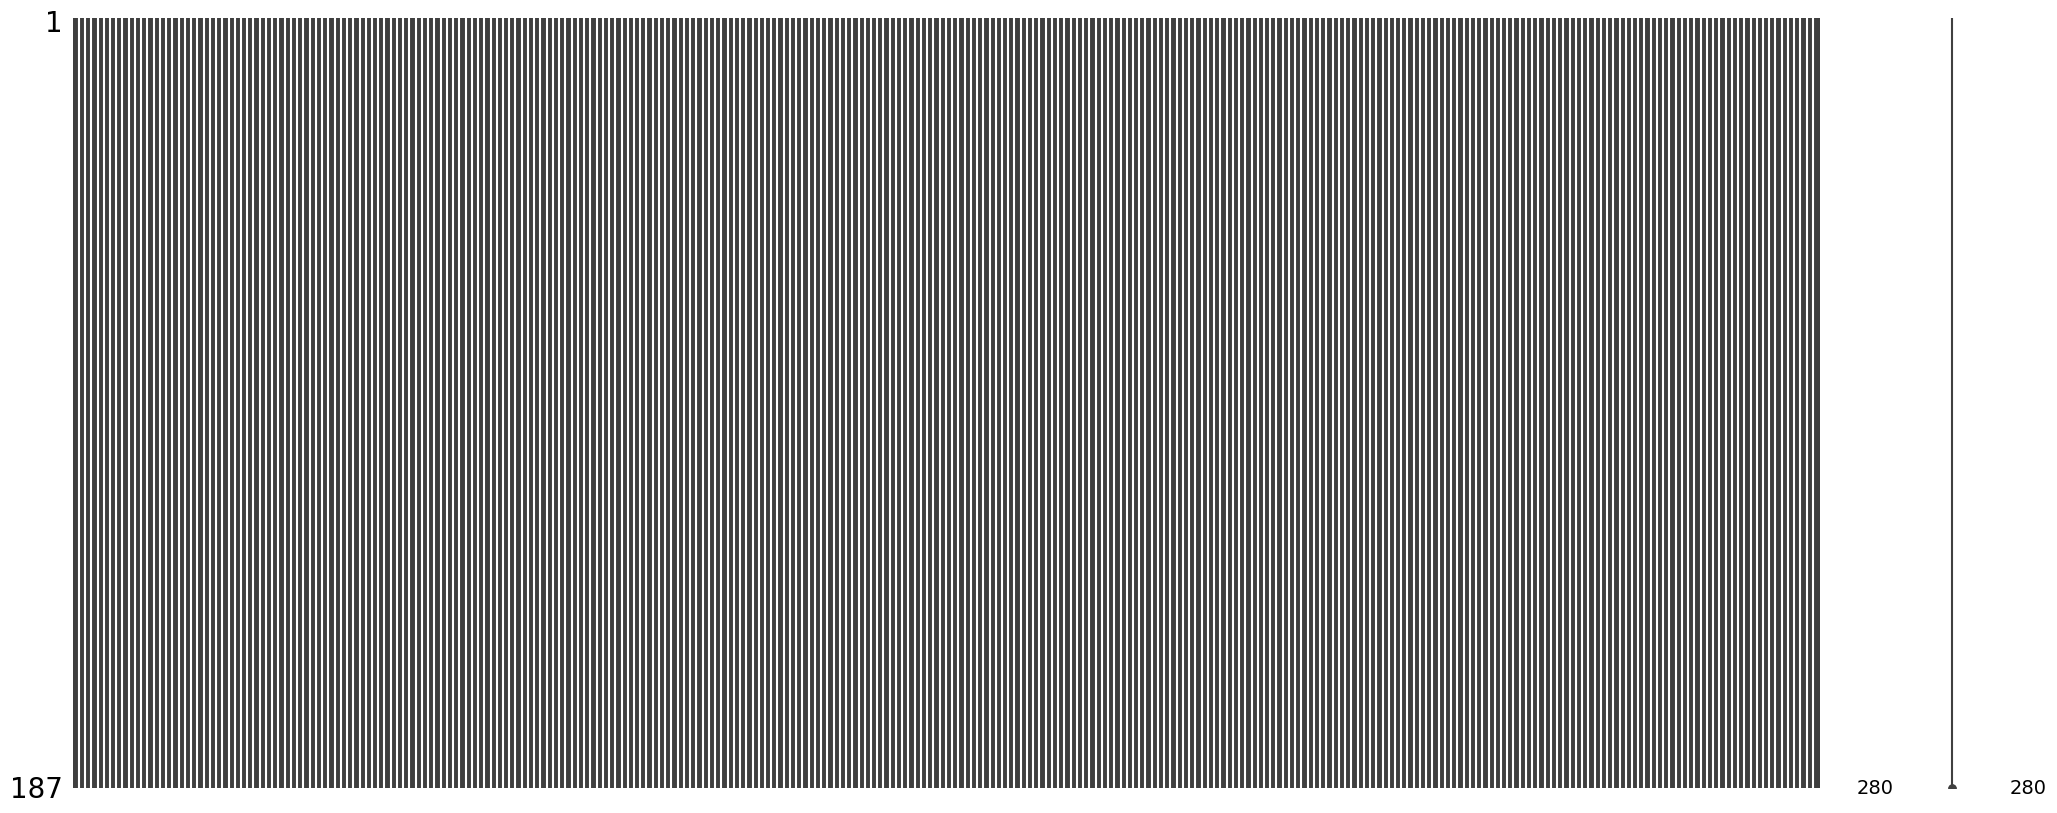

In [33]:
import missingno as mno
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
mno.matrix(CrossSectDict[1800]['raw'])

## Imputation

In [34]:
pipe_kwargs = {}

In [35]:
#imputer = SimpleImputer(strategy='mean')
imputer = KNNImputer
pipe_kwargs['imputer'] = {'default': {'n_neighbors' :7, 'weights': 'distance'}
                          }

## Scale

In [36]:
#scaler = GaussRankScaler()
#scaler = QuantileTransformer(output_distribution='normal')
scaler = StandardScaler
pipe_kwargs['scaler'] = {'default': {}
                         }


## Reducer

In [37]:
reducer = PCA
#reducer = UMAP(n_components=6, n_neighbors=15, min_dist=0., metric='manhattan')
pipe_kwargs['reducer'] = {'default': {'n_components' : 10},
                          'variable': {'n_components': lambda dim: min(dim, 10)}
                          }

## Cluster

In [38]:
#clusterer = HDBSCAN(min_cluster_size=20, min_samples=15, cluster_selection_epsilon=0.5)
#clusterer = KMeans(n_clusters=3)
clusterer = GMM
pipe_kwargs['clusterer'] = {'default': {'n_components': 8},
                            'variable': {'n_components': CLUSTER_NUM_LIST}
                            }

# Run pipeline

In [39]:
ModelDict = {}
ClustDict = defaultdict(lambda: defaultdict(dict))
for period in tqdm(CrossSectDict.keys()):
    ModelDict[period] = {}
    for preptype in CrossSectDict[period].keys():
        df = CrossSectDict[period][preptype].copy()
        # TODO: this is stupid, improve perhaps?
        if pipe_kwargs['reducer'].get('variable'):
            pipe_kwargs['reducer']['default']['n_components'] = pipe_kwargs['reducer']['variable']['n_components'](df.shape[1])

        if pipe_kwargs['clusterer'].get('variable'):
            # assumes variation of number of components
            if isinstance(pipe_kwargs['clusterer']['variable']['n_components'], list):
                for n_comp in pipe_kwargs['clusterer']['variable']['n_components']:
                    pipe_kwargs['clusterer']['default']['n_components'] = n_comp
                    
                    le_pipe_de_prep = Pipeline([
                                ('scaler', scaler(**pipe_kwargs['scaler']['default'])),
                                ('imputer', imputer(**pipe_kwargs['imputer']['default'])),
                                ('reducer', reducer(**pipe_kwargs['reducer']['default']))])
                    
                    le_pipe_clusterer = Pipeline([
                                ('prepper', le_pipe_de_prep),
                                ('clusterer', clusterer(**pipe_kwargs['clusterer']['default']))],
                                verbose=False)   
                    
                    le_pipe_clusterer.fit(df.values)
                    
                    ModelDict[period][preptype] = {}
                    ModelDict[period][preptype][n_comp] = le_pipe_clusterer
                    
                    clust_clf = le_pipe_clusterer.named_steps['clusterer']
                    
                    if ('labels_' in clust_clf.__dir__()) & ('probabilities_' in clust_clf.__dir__()):
                        CrossSectDict[period][preptype][f'cluster_{n_comp}'] = clust_clf.labels_
                        CrossSectDict[period][preptype][f'cluster_proba{n_comp}'] = clust_clf.probabilities_
                    else:
                        prepped_df = le_pipe_clusterer.named_steps['prepper'].transform(df.values)
                        CrossSectDict[period][preptype][f'cluster_{n_comp}'] = le_pipe_clusterer.predict(df.values)
                        CrossSectDict[period][preptype][f'cluster_proba{n_comp}'] = np.max(le_pipe_clusterer.predict_proba(df.values), axis=1)
                        CrossSectDict[period][preptype][f'AIC_{n_comp}'] = clust_clf.aic(prepped_df)
                        CrossSectDict[period][preptype][f'BIC_{n_comp}'] = clust_clf.bic(prepped_df)                   
            else:
                raise ValueError("We expect a list for n_components :)")                
        else:
            le_pipe_de_prep = Pipeline([
                        ('scaler', scaler(**pipe_kwargs['scaler']['default'])),
                        ('imputer', imputer(**pipe_kwargs['imputer']['default'])),
                        ('reducer', reducer(**pipe_kwargs['reducer']['default']))])
            
            le_pipe_clusterer = Pipeline([
                        ('prepper', le_pipe_de_prep),
                        ('clusterer', clusterer(**pipe_kwargs['clusterer']['default']))],
                        verbose=False)  
            le_pipe_clusterer.fit(df.values)
            
            clust_clf = le_pipe_clusterer.named_steps['clusterer']
            if ('labels_' in clust_clf.__dir__()) & ('probabilities_' in clust_clf.__dir__()):
                CrossSectDict[period][preptype]['cluster'] = clust_clf.labels_
                CrossSectDict[period][preptype]['cluster_proba'] = clust_clf.probabilities_
            else:
                prepped_df = le_pipe_clusterer.named_steps['prepper'].transform(df.values)
                CrossSectDict[period][preptype]['cluster'] = le_pipe_clusterer.predict(df.values)
                CrossSectDict[period][preptype]['cluster_proba'] = np.max(le_pipe_clusterer.predict_proba(df.values), axis=1)               
                CrossSectDict[period][preptype]['AIC'] = clust_clf.aic(prepped_df)
                CrossSectDict[period][preptype]['BIC'] = clust_clf.bic(prepped_df)   
            ModelDict[period][preptype] = le_pipe_clusterer
            
        AIC_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if 'AIC' in c]      
        BIC_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if 'BIC' in c]       
        if len(AIC_cols)>0:     
            ClustDict[period][preptype]['AIC'] = {aic_col.split("_")[1]: CrossSectDict[period][preptype][aic_col].mean() for aic_col in AIC_cols}
            ClustDict[period][preptype]['BIC'] = {bic_col.split("_")[1]: CrossSectDict[period][preptype][bic_col].mean() for bic_col in BIC_cols}
            
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if ('cluster_' in c) & ('_proba' not in c)]      
        cluster_proba_cols = [c for c in CrossSectDict[period][preptype].columns 
                                    if 'cluster_proba' in c]
        
        if len(cluster_cols)>0:
            ClustDict[period][preptype]['clusters']= CrossSectDict[period][preptype][cluster_cols]
        if len(cluster_proba_cols)>0:
            ClustDict[period][preptype]['cluster_probas']= CrossSectDict[period][preptype][cluster_proba_cols]

100%|██████████| 3/3 [00:04<00:00,  1.49s/it]


In [40]:
END_TIME = datetime.datetime.now()
DURATION = (END_TIME-START_TIME)

print(f"The runs took about {END_TIME-START_TIME} h/s")

The runs took about 0:01:29.361576 h/s


## Plot

In [41]:
aic_list = []
bic_list = []
for period in tqdm(ClustDict.keys()):
    for preptype in ClustDict[period].keys():
        tDict = ClustDict[period][preptype]['AIC'].copy()
        tDict['period'] = period
        tDict['preptype'] = preptype        
        aic_list.append(tDict)
        
        tDict = ClustDict[period][preptype]['BIC'].copy()
        tDict['period'] = period
        tDict['preptype'] = preptype        
        bic_list.append(tDict)
        
aic_df = pd.DataFrame(aic_list).set_index(['period', 'preptype']).T
aic_df.columns = ['_'.join([str(_c) for _c in col]).strip() for col in aic_df.columns.values]

bic_df = pd.DataFrame(bic_list).set_index(['period', 'preptype']).T
bic_df.columns = ['_'.join([str(_c) for _c in col]).strip() for col in bic_df.columns.values]

min_aic_ind = [{c: aic_df.index[aic_df[c].argmin()]} for c in aic_df.columns]
min_bic_ind = [{c: bic_df.index[bic_df[c].argmin()]} for c in bic_df.columns]

100%|██████████| 3/3 [00:00<00:00, 3006.67it/s]


In [42]:
aic_df

,720_smoothed,720_raw,720_merged,1800_smoothed,1800_raw,1800_merged,3600_smoothed,3600_raw,3600_merged
4,14945.115966,15379.067557,17122.999764,9841.833948,9885.722494,11072.400553,5474.554171,5646.282811,6193.687820
8,14202.983738,14882.371133,16377.568119,9812.651292,9643.094369,10959.162377,4521.125942,4672.638049,5440.063227
16,12682.148660,13849.611516,15130.030477,7825.590517,8500.864340,9104.071143,1424.483532,1426.615524,1132.306524
32,7366.225560,8726.185202,9611.058515,690.566699,1071.297273,1431.580421,-1923.344036,-1711.708100,-1758.949661


In [43]:
bic_df

,720_smoothed,720_raw,720_merged,1800_smoothed,1800_raw,1800_merged,3600_smoothed,3600_raw,3600_merged
4,15917.451553,16351.403144,18095.335351,10691.615514,10735.504060,11922.182120,6159.713930,6331.442570,6878.847579
8,16151.352005,16830.739401,18325.936387,11515.445533,11345.888610,12661.956618,5894.050630,6045.562737,6812.987915
16,16582.582288,17750.045144,19030.464106,11234.410107,11909.683931,12512.890734,4172.938078,4175.070070,3880.761070
32,15170.789910,16530.749552,17415.622865,7511.436990,7892.167564,8252.450711,3576.170226,3787.806162,3740.564601


In [44]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        RangeDFDict['raw'][period] = \
            pd.merge(RangeDFDict['raw'][period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

100%|██████████| 3/3 [00:00<00:00, 44.93it/s]


In [45]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        RangeDFDict_smoothed['raw'][period] = \
            pd.merge(RangeDFDict_smoothed['raw'][period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

100%|██████████| 3/3 [00:00<00:00, 44.57it/s]


In [46]:
RangeDFDict_smoothed['raw'].keys()

dict_keys([720, 1800, 3600])

In [47]:
RangeDFDict_smoothed['raw'][720]

,ID,Time_days,eGFR_int,cluster_4,cluster_proba4,AIC_4,BIC_4,cluster_8,cluster_proba8,AIC_8,...,AIC_8_merged,BIC_8_merged,cluster_16_merged,cluster_proba16_merged,AIC_16_merged,BIC_16_merged,cluster_32_merged,cluster_proba32_merged,AIC_32_merged,BIC_32_merged
0,3565782,0,102.886825,1,0.96567,14945.115966,15917.451553,4,0.999999,14202.983738,...,16377.568119,18325.936387,3,1.0,15130.030477,19030.464106,2,1.0,9611.058515,17415.622865
1,3565782,30,120.490852,1,0.96567,14945.115966,15917.451553,4,0.999999,14202.983738,...,16377.568119,18325.936387,3,1.0,15130.030477,19030.464106,2,1.0,9611.058515,17415.622865
2,3565782,60,122.444113,1,0.96567,14945.115966,15917.451553,4,0.999999,14202.983738,...,16377.568119,18325.936387,3,1.0,15130.030477,19030.464106,2,1.0,9611.058515,17415.622865
3,3565782,90,124.795396,1,0.96567,14945.115966,15917.451553,4,0.999999,14202.983738,...,16377.568119,18325.936387,3,1.0,15130.030477,19030.464106,2,1.0,9611.058515,17415.622865
4,3565782,120,127.104318,1,0.96567,14945.115966,15917.451553,4,0.999999,14202.983738,...,16377.568119,18325.936387,3,1.0,15130.030477,19030.464106,2,1.0,9611.058515,17415.622865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7147,18636225350,570,99.116577,3,1.00000,14945.115966,15917.451553,7,1.000000,14202.983738,...,16377.568119,18325.936387,2,1.0,15130.030477,19030.464106,19,1.0,9611.058515,17415.622865
7148,18636225350,600,99.994818,3,1.00000,14945.115966,15917.451553,7,1.000000,14202.983738,...,16377.568119,18325.936387,2,1.0,15130.030477,19030.464106,19,1.0,9611.058515,17415.622865
7149,18636225350,630,100.972368,3,1.00000,14945.115966,15917.451553,7,1.000000,14202.983738,...,16377.568119,18325.936387,2,1.0,15130.030477,19030.464106,19,1.0,9611.058515,17415.622865
7150,18636225350,660,101.828208,3,1.00000,14945.115966,15917.451553,7,1.000000,14202.983738,...,16377.568119,18325.936387,2,1.0,15130.030477,19030.464106,19,1.0,9611.058515,17415.622865


Text(0.5, 1.0, 'Raw 3640 days')

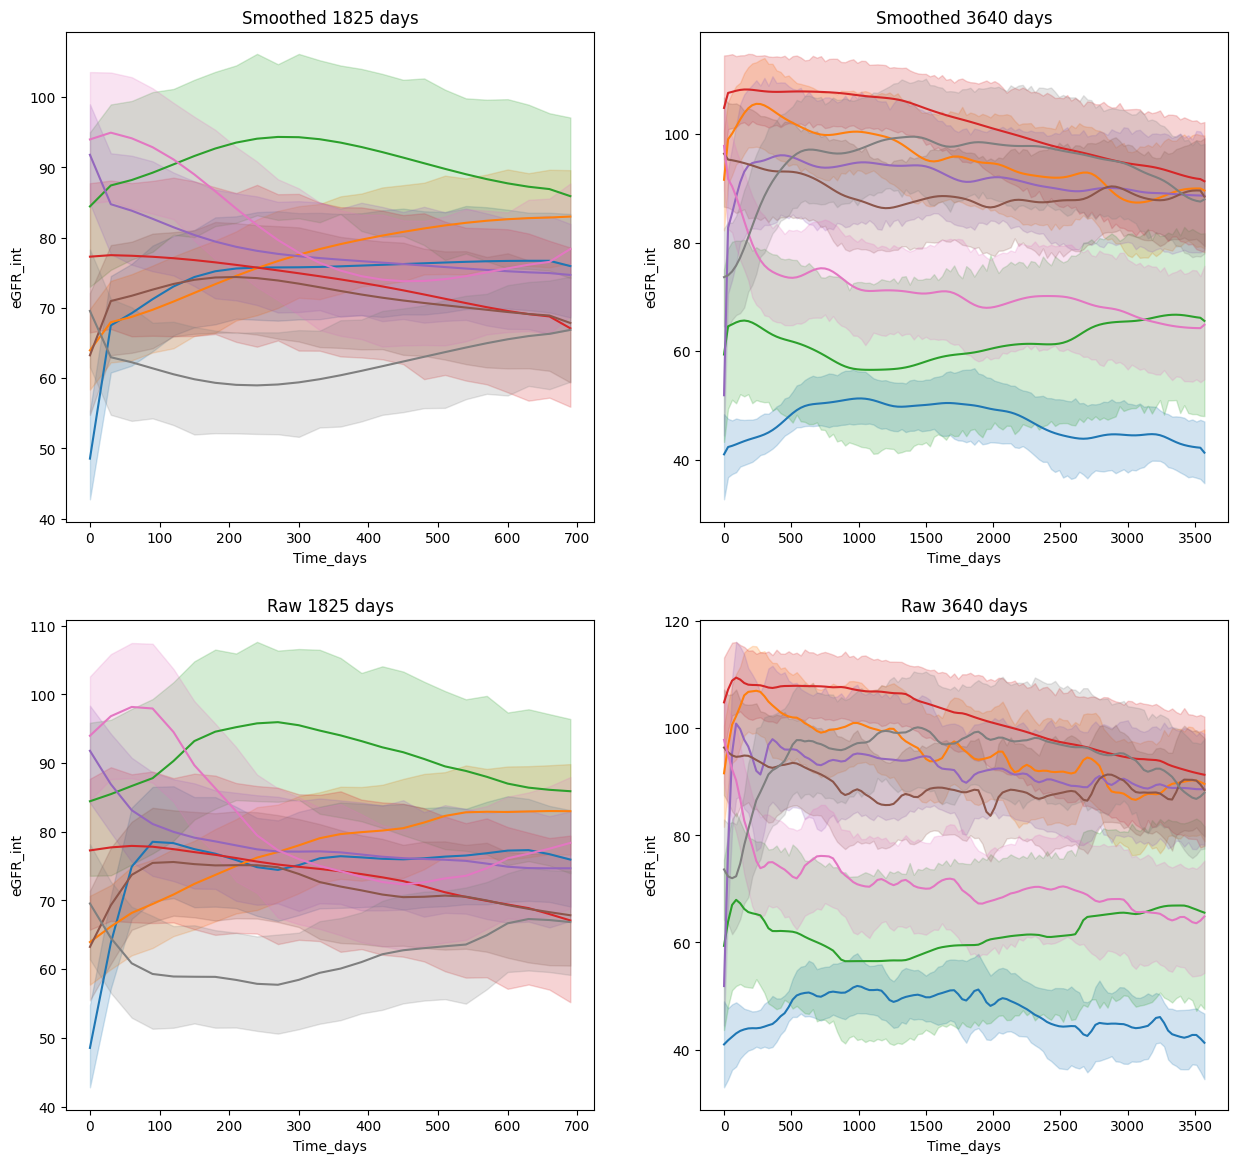

In [48]:
#sns.color_palette("tab10")

fig, ax = plt.subplots(figsize=(15, 14), ncols=2, nrows=2)

sns.lineplot(data=RangeDFDict_smoothed['raw'][720], 
             x=TIME_COL,
             y=VAL_COL,
             hue='cluster_8_merged',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             legend=False,
             ax=ax[0,0]
             )

sns.lineplot(data=RangeDFDict_smoothed['raw'][3600], 
             x=TIME_COL,
             y=VAL_COL,
             hue='cluster_8_merged',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             legend=False,
             ax=ax[0,1]
             )

sns.lineplot(data=RangeDFDict['raw'][720], 
             x=TIME_COL,
             y=VAL_COL,
             hue='cluster_8_merged',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             legend=False,
             ax=ax[1,0]
             )

sns.lineplot(data=RangeDFDict['raw'][3600], 
             x=TIME_COL,
             y=VAL_COL,
             hue='cluster_8_merged',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             legend=False,
             ax=ax[1,1]
             )
ax[0,0].set_title("Smoothed 1825 days")
ax[0,1].set_title("Smoothed 3640 days")
ax[1,0].set_title("Raw 1825 days")
ax[1,1].set_title("Raw 3640 days")

In [49]:
RangeDFDict_smoothed['raw'][720].ID.nunique()

298

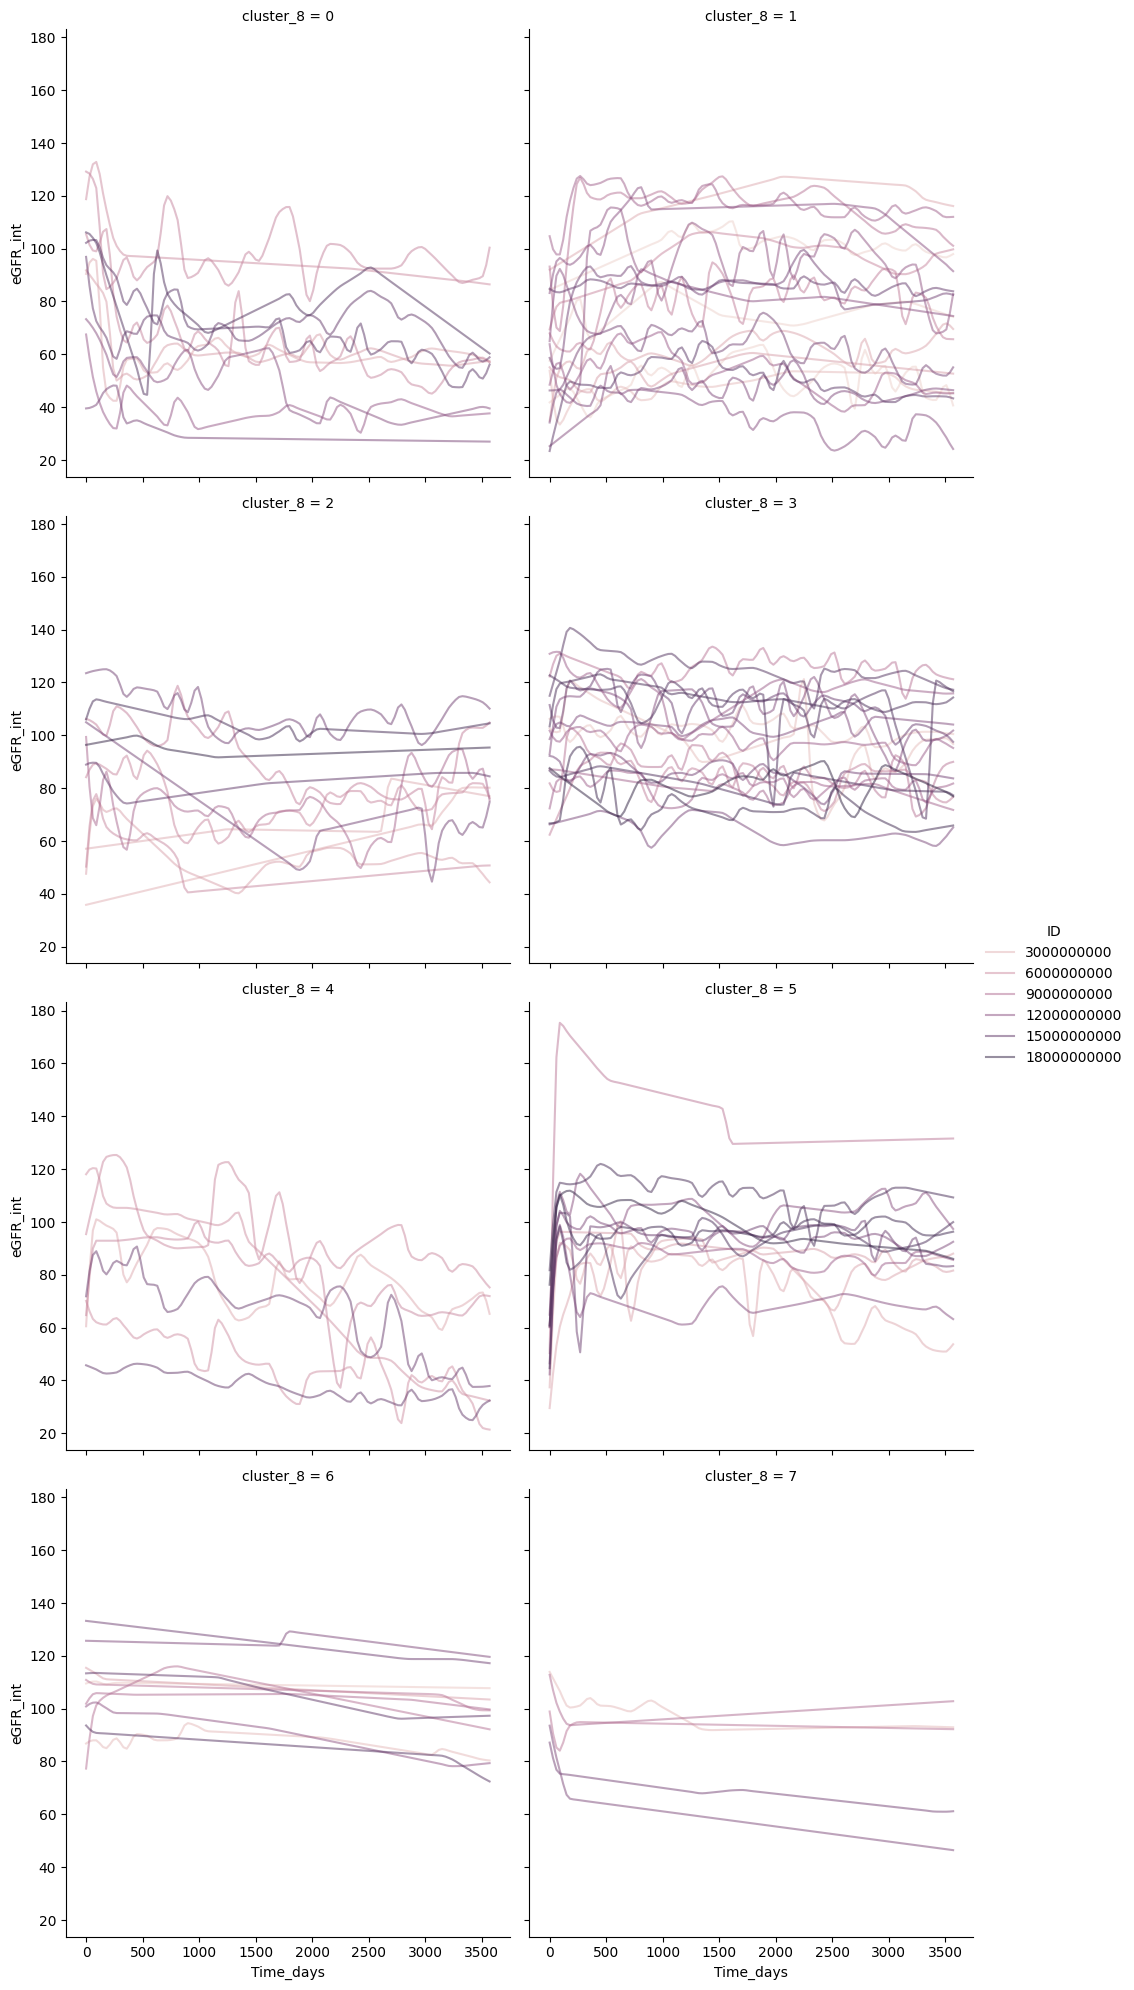

In [50]:
# select maximally 50 patients per cluster
df = RangeDFDict['raw'][3600]
sample_size = 100
sample_selection = df.groupby('cluster_8').ID.sample(n=sample_size).values
sns.relplot(data=df.loc[df[ID_COL].isin(sample_selection)], 
             x=TIME_COL,
             y=VAL_COL,
             hue=ID_COL,
             kind='line',
             col='cluster_8',
             col_wrap=2,
             alpha=.5,
             color='black'
             )

## Compare our results with the reference results

* Jaccard
* Adjusted Mutual information
* Adjusted Rand-index

In [ ]:
RangeDFDict_smoothed.keys()

In [ ]:
OurResult = RangeDFDict_smoothed['raw'][3600][['ID', 'cluster_8', 'cluster_8_raw', 'cluster_8_merged']]\
                                .drop_duplicates()
OurResult.set_index('ID', inplace=True)
#
LCCMResult = PRESELECT_PATIENT_CLASSES[['ID', 'class']]
LCCMResult.set_index('ID', inplace=True)
#
RandomResult = OurResult.copy()
RandomResult['cluster_10'] = np.random.randint(0,10, size=OurResult.shape[0])
RandomResult['cluster_10_raw'] = np.random.randint(0,10, size=OurResult.shape[0])
RandomResult['cluster_10_merged'] = np.random.randint(0,10, size=OurResult.shape[0])

In [ ]:
from sklearn.metrics import adjusted_mutual_info_score as ami, adjusted_rand_score as ari
from sklearn.metrics import normalized_mutual_info_score as nmi

In [ ]:
RandomResult.columns = [f'random_{c}' for c in RandomResult.columns]
OurResult.columns = [f'timex_{c}' for c in OurResult.columns]
LCCMResult.columns = [f'lcmm_{c}' for c in LCCMResult.columns]
LCCMResult.index  = LCCMResult.index.astype('int64')

In [ ]:
MergedResults = OurResult.join(RandomResult, how='inner').join(LCCMResult,  how='inner')

In [ ]:
sns.heatmap(MergedResults.corr(method=ari), cmap="crest")

In [ ]:
sns.heatmap(MergedResults.corr(method=nmi), cmap="crest")

In [ ]:
MergedResults.corr(method=nmi)

In [ ]:
preselection.ID = preselection.ID.astype('int64')

In [ ]:
sns.relplot(data=preselection.query('Time_days<3650 and Class=="Observed"'), 
             x='Time_days',
             y='eGFR',
             hue='ID',
             kind='line',
             col='class',
             col_wrap=2,
             alpha=0.05,
             color='black'
             )